In [1]:
%load_ext autoreload
%autoreload 2


import matplotlib.pyplot as plt
import numpy as np

from darkmod import laue
from darkmod.beam import GaussianLineBeam
from darkmod.crl import CompundRefractiveLens
from darkmod.crystal import Crystal
from darkmod.detector import Detector
from darkmod.resolution import PentaGauss

In [2]:
plt.style.use("dark_background")
fontsize = 16  # General font size for all text
ticksize = 16  # tick size
plt.rcParams["font.size"] = fontsize
plt.rcParams["xtick.labelsize"] = ticksize
plt.rcParams["ytick.labelsize"] = ticksize

In [3]:
beta_field = np.load("beta_field.npy")
deformation_gradient_field = beta_field.copy()
for i in range(3):
    deformation_gradient_field[..., i, i] += 1
voxel_size = 0.143  # microns

In [4]:
number_of_lenses = 88
lens_space = 1600  # microns
lens_radius = 50  # microns
magnification = 18.4742
energy = 17.1  # keV
unit_cell = [4.0493, 4.0493, 4.0493, 90.0, 90.0, 90.0]  # angstrom
Z = 4  # atomic number, berillium
rho = 1.845  # density, berillium, g/cm^3
A = 9.0121831  # atomic mass number, berillium, g/mol

hkl = np.array([1, 1, 1])
eta = np.radians(0)
orientation = np.array(
    [
        [0.408248290463863, -0.816496580927726, 0.408248290463863],
        [0.707106781186547, 0.0, -0.707106781186547],
        [0.577350269189626, 0.577350269189626, 0.577350269189626],
    ]
)
z_std = 0.3  # microns
crystal = Crystal(unit_cell, orientation)
d = np.pi * 2 / np.linalg.norm(crystal.U @ crystal.B @ hkl)
theta = np.arcsin(laue.keV_to_angstrom(energy) / (2 * d))


# Beam divergence params
beam_FWHM_vertical = 0.027 * 1e-3
beam_FWHM_horizontal = 1e-9

# Beam wavelength broadening
sigma_e = (6 * 1e-5) / (2 * np.sqrt(2 * np.log(2)))

# crl acceptance
FWHM_CRL_vertical = 0.556 * 1e-3
FWHM_CRL_horizontal = FWHM_CRL_vertical

# Detector size
det_row_count = 812
det_col_count = 512
pixel_size = 0.65
super_sampling = 2
dynamic_range = 2**16 - 1
exposure = 1000
psf_width = 1
noise = True

spatial_artefact = False

phi_0 = -theta
phi_step = np.radians(2 * 1e-3) / 8
delta_phi_values = np.arange(0, 80 * phi_step, phi_step)
delta_phi_values -= np.median(delta_phi_values)
phi_values = phi_0 + delta_phi_values

In [5]:
np.degrees(theta)

8.920713583609885

In [6]:
dx, dy, dz = np.array(deformation_gradient_field.shape[0:3]) * voxel_size
xg = np.arange(0, dx, voxel_size)
yg = np.arange(0, dy, voxel_size)
zg = np.arange(0, dz, voxel_size)
xg -= np.median(xg)
yg -= np.median(yg)
zg -= np.median(zg)
Xgrid, Ygrid, Zgrid = np.meshgrid(xg, yg, zg, indexing="ij")
crystal.discretize(Xgrid, Ygrid, Zgrid, deformation_gradient_field)
crystal.goniometer.goto(phi=phi_0, chi=0, omega=0, mu=0)

In [7]:
# np.linalg.inv(crystal.U @ crystal.B) @ np.array([0,0,1])
delta = laue.refractive_decrement(Z, rho, A, energy)
crl = CompundRefractiveLens(
    number_of_lenses, lens_space, lens_radius, delta, magnification
)
crl.goto(theta, eta)
lambda_0 = laue.keV_to_angstrom(energy)
beam = GaussianLineBeam(z_std=z_std, energy=energy)  # 100 nm = 0.1 microns

In [9]:
epsilon = np.random.normal(0, sigma_e, size=(20000,))
random_energy = energy + epsilon * energy
sigma_lambda = laue.keV_to_angstrom(random_energy).std()

resolution_function = PentaGauss(
    crl.optical_axis,
    beam_FWHM_horizontal / (2 * np.sqrt(2 * np.log(2))),
    # desired_FWHM_N / (2 * np.sqrt(2 * np.log(2))),
    beam_FWHM_vertical / (2 * np.sqrt(2 * np.log(2))),
    FWHM_CRL_horizontal / (2 * np.sqrt(2 * np.log(2))),
    FWHM_CRL_vertical / (2 * np.sqrt(2 * np.log(2))),
    lambda_0,
    sigma_lambda,
)
resolution_function.compile()


In [10]:
detector = Detector.wall_mount(
    crl,
    pixel_size,
    det_row_count,
    det_col_count,
    super_sampling=super_sampling,
    exposure=exposure,
    dynamic_range=dynamic_range,
    psf_width=psf_width,
    noise=noise,
)

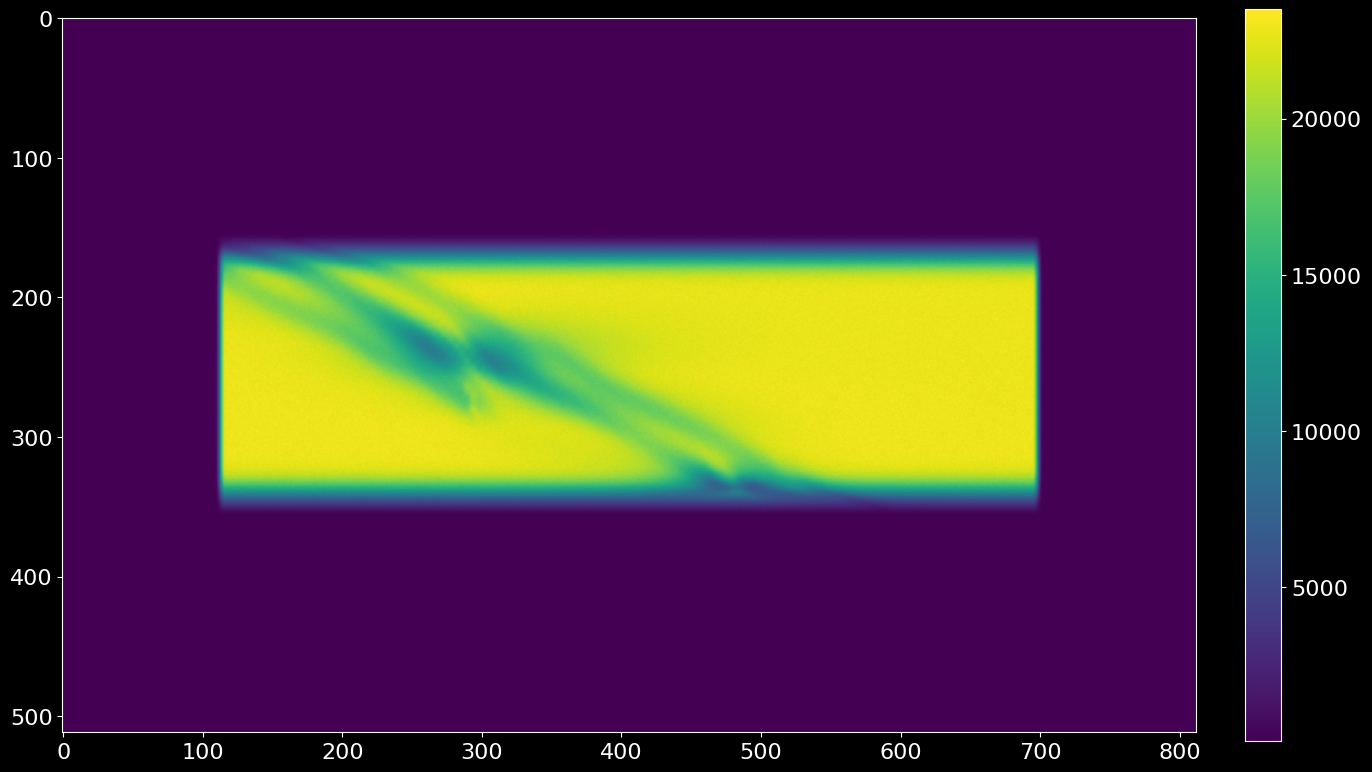

In [11]:
im = crystal.diffract(
    hkl,
    resolution_function,
    crl,
    detector,
    beam,
    spatial_artefact=spatial_artefact,
)

plt.style.use("dark_background")
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
im = ax.imshow(im)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
plt.tight_layout()
plt.show()

NameError: name 'theta' is not defined

In [27]:
image_stack = np.zeros(
    (
        detector.det_col_count,  # Number of detector rows
        detector.det_row_count,  # Number of detector columns
        len(phi_values),  # Number of phi angle steps
    ),
    dtype=detector.dtype,
)

for i in range(phi_values.shape[0]):
    crystal.goniometer.goto(phi=phi_values[i], chi=0, omega=0, mu=0)
    image_stack[..., i] = crystal.diffract(
        hkl,
        resolution_function,
        crl,
        detector,
        beam,
        spatial_artefact=spatial_artefact,
    )
crystal.goniometer.goto(phi=phi_0, chi=0, omega=0, mu=0)

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import IntSlider, interact

# Example data (n,m,d)
n, m, d = image_stack.shape


def show_slice(idx):
    plt.figure(figsize=(12, 14))
    plt.imshow(image_stack[:, :, idx], cmap="viridis")
    plt.title(f"Slice {idx}")
    plt.colorbar(fraction=0.03, pad=0.04)
    plt.show()


interact(show_slice, idx=IntSlider(min=0, max=d - 1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='idx', max=79), Output()), _dom_classes=('widget-interact…

<function __main__.show_slice(idx)>